In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')


In [28]:
from sklearn.linear_model import LinearRegression

Base de datos bitacora de piso

In [13]:
#Carga desde un archivo .csv sin indice
bit = pd.read_csv('Analisis_GAC_Full7agosto_2026_Bitacora_de_Piso.csv', encoding='utf-8-sig')

#Eliminamos columnas vacias sin nombre generadas al final del csv
bit = bit.iloc[:, :18]
bit.columns = [c.strip() for c in bit.columns]

print("Forma original:", bit.shape)
bit.head()

Forma original: (234, 18)


,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,True,Sí hubo prueba de manejo.,"El cliente acudió con una prima, para ella ser...","Sí hubo interacción del gerente, los cliente s...","Sí hubo proceso wow, se recibío al cliente con...",Tiempo de compra hasta el próximo año.,El cliente llego ocasionalmente antes de llega...,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,True,La clienta piensa acudir con sus hijos para ha...,Es una decisión que prefiere tomar con sus hijos.,Sí hubo intervención del Gerente. Converse con...,"Sí hubo un proceso wow, además de la interacci...",NaN,Clienta viene buscando opciones para ella y su...,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,True,"Sí hubo prueba de manejo por la tarde, ya que ...",Ingresa SDC con el perfil de ella y el de su e...,Sí hubo intervención del gerente en las dos vi...,Calificación 5,No se formalizo la venta ya que fue rechazado ...,El cliente visito la agencia porque iba pasand...,NaN
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,True,El cliente no quiso porque sabe que no se encu...,El cliente comenta que en este momento tiene c...,"Sí hubo intervención y me comento su estatus, ...",Calificación 5,Porque por el momento no cuenta con moviemient...,El Señor Elvis se encuentra evaluando diferent...,NaN
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,True,NaN,NaN,NaN,NaN,NaN,El cliente se encuentra en busqueda de renovar...,NaN


In [14]:
bit.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [15]:
#Identificar valores nulos por columna
valores_nulos = bit.isnull().sum()
valores_nulos

Fecha                                          36
Nombre Cliente                                 37
Telefono                                      234
Asesor                                         38
Esatus Lead                                    37
PDM                                             0
SDC                                            18
Estatus de SDC                                232
Venta                                          18
Temperatura                                   224
Inter Gerente                                  18
¿Por que no hubo prueba de manejo?            218
¿Por que no hubo Solicitud de credito?        220
¿Por que no hubo intervencion del Gerente?    223
¿Por que no hubo proceso wow?                 222
¿Por que no se ha formalizado la compra?      223
5 porques clientes de piso                    226
Comentarios                                   212
dtype: int64

In [16]:
#Eliminamos filas "basura" (sin Fecha, sin Cliente y sin Asesor) generadas por el csv
#Metodo de ELIMINACION de valores nulos aplicado a filas totalmente vacias
filas_vacias = bit['Fecha'].isnull() & bit['Nombre Cliente'].isnull() & bit['Asesor'].isnull()
print("Filas vacias detectadas:", filas_vacias.sum())

bit = bit.loc[~filas_vacias].reset_index(drop=True)
print("Forma tras eliminar filas vacias:", bit.shape)

Filas vacias detectadas: 36
Forma tras eliminar filas vacias: (198, 18)


In [17]:
bit_clean = bit.copy()

# Normalización directa con lambda
for c in ['Esatus Lead', 'Estatus de SDC', 'Temperatura', 'Asesor']:
    bit_clean[c] = bit_clean[c].apply(
        lambda x: re.sub(r'\s+', ' ', 
                         unicodedata.normalize('NFKD', str(x).strip().upper())
                         .encode('ascii', 'ignore')
                         .decode('utf-8')
                        ).strip()
        if pd.notna(x) else x
    )

bit_clean.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,AURELIO,ACTIVO,True,False,NaN,False,LEAD INTERESBAJO,True,Sí hubo prueba de manejo.,"El cliente acudió con una prima, para ella ser...","Sí hubo interacción del gerente, los cliente s...","Sí hubo proceso wow, se recibío al cliente con...",Tiempo de compra hasta el próximo año.,El cliente llego ocasionalmente antes de llega...,NaN
1,04/01/2025,Olivia Cabello,NaN,PEDRO,ACTIVO,False,False,NaN,False,LEAD INTERESBAJO,True,La clienta piensa acudir con sus hijos para ha...,Es una decisión que prefiere tomar con sus hijos.,Sí hubo intervención del Gerente. Converse con...,"Sí hubo un proceso wow, además de la interacci...",NaN,Clienta viene buscando opciones para ella y su...,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,MAURICIO,ACTIVO,True,True,ANALISIS,True,LEAD INTERES ALTO,True,"Sí hubo prueba de manejo por la tarde, ya que ...",Ingresa SDC con el perfil de ella y el de su e...,Sí hubo intervención del gerente en las dos vi...,Calificación 5,No se formalizo la venta ya que fue rechazado ...,El cliente visito la agencia porque iba pasand...,NaN
3,04/02/2025,Elvis Sanchez,NaN,AURELIO,ACTIVO,False,False,NaN,False,LEAD INTERESBAJO,True,El cliente no quiso porque sabe que no se encu...,El cliente comenta que en este momento tiene c...,"Sí hubo intervención y me comento su estatus, ...",Calificación 5,Porque por el momento no cuenta con moviemient...,El Señor Elvis se encuentra evaluando diferent...,NaN
4,04/03/2025,Ariel Fernando López,NaN,ALAN,ACTIVO,True,False,NaN,False,NaN,True,NaN,NaN,NaN,NaN,NaN,El cliente se encuentra en busqueda de renovar...,NaN


In [18]:
#Metodo de SUSTITUCION de valores nulos con la MODA para las columnas booleanas
#(PDM, SDC, Venta, Inter Gerente): si no quedo registrado, se asume el valor mas frecuente
for c in ['PDM', 'SDC', 'Venta', 'Inter Gerente']:
    moda = bit_clean[c].mode(dropna=True)[0]
    bit_clean[c] = bit_clean[c].fillna(moda).astype(int)

valores_nulos = bit_clean[['PDM','SDC','Venta','Inter Gerente']].isnull().sum()
valores_nulos


PDM              0
SDC              0
Venta            0
Inter Gerente    0
dtype: int64

In [19]:
#Convertimos "Temperatura" (categorica) a una escala numerica ordinal (1=frio, 5=muy caliente)
temp_map = {
    'LEAD INTERESBAJO': 1,
    'TIBIO': 2,
    'LEAD INTERES MEDIO': 3,
    'LEAD INTERES ALTO': 4,
    'EBULLICION': 5
}
bit_clean['Temperatura_Nivel'] = bit_clean['Temperatura'].map(temp_map)

#Sustituimos nulos de la nueva variable numerica con la MEDIANA
bit_clean['Temperatura_Nivel'] = bit_clean['Temperatura_Nivel'].fillna(
    round(bit_clean['Temperatura_Nivel'].median()))

#Convertimos "Esatus Lead" a variable binaria numerica "Lead_Cerrado"
bit_clean['Esatus Lead'] = bit_clean['Esatus Lead'].fillna('SIN DATO')
bit_clean['Lead_Cerrado'] = bit_clean['Esatus Lead'].isin(
    ['VENTA', 'FINALIZADO', 'CERRADO']).astype(int)

bit_clean[['Temperatura','Temperatura_Nivel','Esatus Lead','Lead_Cerrado']].head(10)

,Temperatura,Temperatura_Nivel,Esatus Lead,Lead_Cerrado
0,LEAD INTERESBAJO,1.0,ACTIVO,0
1,LEAD INTERESBAJO,1.0,ACTIVO,0
2,LEAD INTERES ALTO,4.0,ACTIVO,0
3,LEAD INTERESBAJO,1.0,ACTIVO,0
4,NaN,2.0,ACTIVO,0
5,NaN,2.0,ACTIVO,0
6,LEAD INTERES ALTO,4.0,CERRADO,1
7,NaN,2.0,VENTA,1
8,NaN,2.0,ACTIVO,0
9,NaN,2.0,ACTIVO,0


In [20]:
#Corroboramos valores nulos en todo el DataFrame limpio
#Al principio tenia una parte del codigo que eliminaba todas las columnas que no fueran numericas
#pero desidi dejarlas porque simplemente me voy a centrar a convertir algunas cosas al tipo numerico
#para el ejercicio de esta tarea, y el csv generado, es unicamente para las correlaciones, 
#ya contamos con la base completamente limpia en la actividad 4.2
valores_nulos = bit_clean.isnull().sum()
valores_nulos

Fecha                                           0
Nombre Cliente                                  1
Telefono                                      198
Asesor                                          2
Esatus Lead                                     0
PDM                                             0
SDC                                             0
Estatus de SDC                                196
Venta                                           0
Temperatura                                   188
Inter Gerente                                   0
¿Por que no hubo prueba de manejo?            182
¿Por que no hubo Solicitud de credito?        184
¿Por que no hubo intervencion del Gerente?    187
¿Por que no hubo proceso wow?                 186
¿Por que no se ha formalizado la compra?      187
5 porques clientes de piso                    190
Comentarios                                   176
Temperatura_Nivel                               0
Lead_Cerrado                                    0


In [21]:
#Verificamos que las columnas de interes ya son de tipo numerico
numericas_bit = ['PDM', 'SDC', 'Venta', 'Inter Gerente', 'Temperatura_Nivel', 'Lead_Cerrado']
bit_clean[numericas_bit].dtypes

PDM                    int64
SDC                    int64
Venta                  int64
Inter Gerente          int64
Temperatura_Nivel    float64
Lead_Cerrado           int64
dtype: object

<Figure size 1000x600 with 0 Axes>

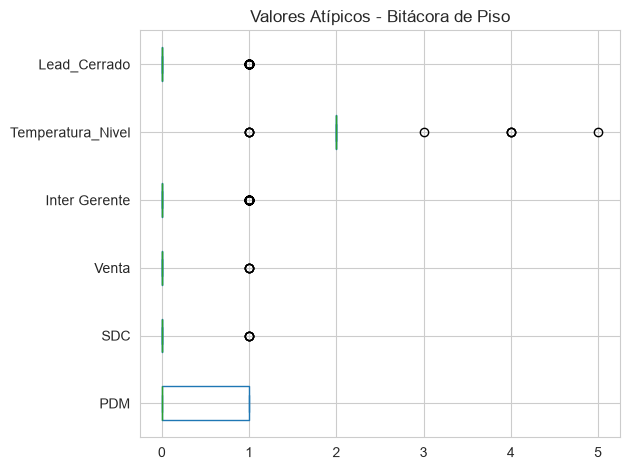

In [22]:
#Realizamos diagrama de caja o bigote de cada variable numerica del dataframe
fig = plt.figure(figsize=(10, 6))
bit_clean[numericas_bit].plot(kind='box', vert=False)
plt.title("Valores Atípicos - Bitácora de Piso")
plt.tight_layout()
plt.show()

In [23]:
#Metodo IQR: encontramos los limites y contamos outliers por variable
#(son variables binarias 0/1 o de escala 1-5, por lo que casi no hay atipicos reales:
# esto confirma que los datos ya son consistentes tras el tratamiento de nulos)
for c in numericas_bit:
    Q1 = bit_clean[c].quantile(0.25)
    Q3 = bit_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = bit_clean[(bit_clean[c] < li) | (bit_clean[c] > ls)]
    print(f"{c}: limites=({li:.2f}, {ls:.2f}) | outliers detectados={len(outliers)}")

PDM: limites=(-1.50, 2.50) | outliers detectados=0
SDC: limites=(0.00, 0.00) | outliers detectados=4
Venta: limites=(0.00, 0.00) | outliers detectados=4
Inter Gerente: limites=(0.00, 0.00) | outliers detectados=31
Temperatura_Nivel: limites=(2.00, 2.00) | outliers detectados=9
Lead_Cerrado: limites=(0.00, 0.00) | outliers detectados=29


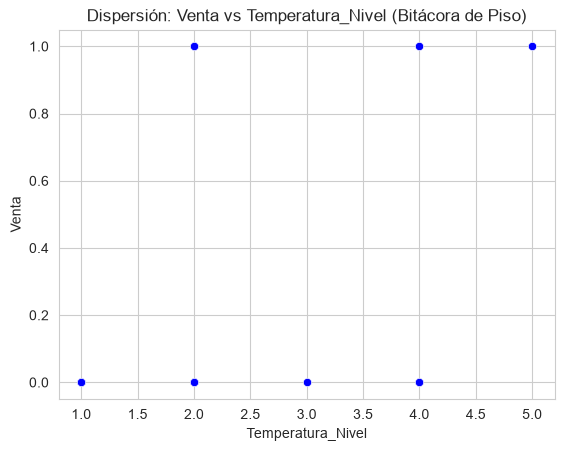

In [24]:
#Usamos el DataFrame limpio de Bitacora de Piso (bit_clean) de la seccion 1
df_bitacora_reg = bit_clean[['Temperatura_Nivel', 'Venta']].dropna()

#Imprimimos el scatter plot entre la variable dependiente (Venta) y la
#independiente (Temperatura_Nivel) para observar el comportamiento de su dispersión
sns.scatterplot(x='Temperatura_Nivel', y='Venta', color='blue', data=df_bitacora_reg)
plt.title('Dispersión: Venta vs Temperatura_Nivel (Bitácora de Piso)')
plt.show()


In [64]:
#Declaramos variable dependiente e independiente y ajustamos el modelo
Var_Dep = df_bitacora_reg['Venta']
Vars_Indep = df_bitacora_reg[['Temperatura_Nivel']]

model_bitacora = LinearRegression()
model_bitacora.fit(X=Vars_Indep, y=Var_Dep)

m = model_bitacora.coef_[0]
b = model_bitacora.intercept_
coef_Deter = model_bitacora.score(Vars_Indep, Var_Dep)
coef_Correl = np.sqrt(coef_Deter) if m >= 0 else -np.sqrt(coef_Deter)

print(f"Modelo matematico: Venta = {m:.4f} * Temperatura_Nivel + {b:.4f}")
print(f"Coeficiente de Determinacion R2 = {coef_Deter:.4f}")
print(f"Coeficiente de Correlacion r = {coef_Correl:.4f}")
print("\nAdvertencia: Venta es binaria (0/1); una recta no puede ajustar bien este tipo de variable.")
print("El resultado es orientativo; lo estadisticamente correcto seria una regresion logistica.")

Modelo matematico: Venta = 0.1890 * Temperatura_Nivel + -0.3635
Coeficiente de Determinacion R2 = 0.2352
Coeficiente de Correlacion r = 0.4850

Advertencia: Venta es binaria (0/1); una recta no puede ajustar bien este tipo de variable.
El resultado es orientativo; lo estadisticamente correcto seria una regresion logistica.


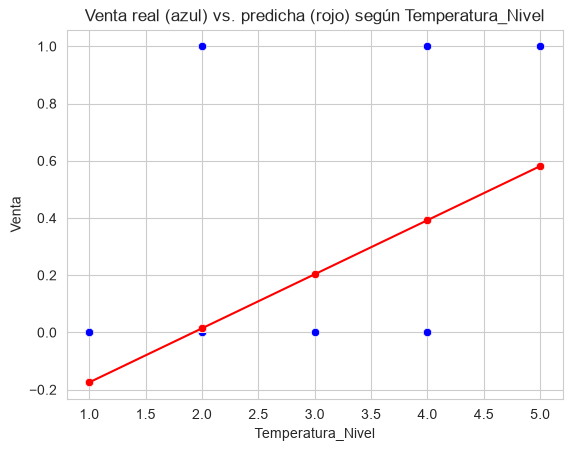

In [65]:
#Visualizamos la grafica comparativa entre la Venta real y la predicha
df_bitacora_reg['Predicciones'] = model_bitacora.predict(Vars_Indep)

sns.scatterplot(x='Temperatura_Nivel', y='Venta', color='blue', data=df_bitacora_reg)
sns.scatterplot(x='Temperatura_Nivel', y='Predicciones', color='red', data=df_bitacora_reg)
sns.lineplot(x='Temperatura_Nivel', y='Predicciones', color='red', data=df_bitacora_reg)
plt.title('Venta real (azul) vs. predicha (rojo) según Temperatura_Nivel')
plt.show()

In [29]:
#Matriz de correlacion de las variables numericas
Corr_Bitacora = bit_clean[numericas_bit].corr()
Corr_Bitacora

,PDM,SDC,Venta,Inter Gerente,Temperatura_Nivel,Lead_Cerrado
PDM,1.000000,0.183887,0.035880,0.265241,0.078635,-0.205682
SDC,0.183887,1.000000,0.234536,0.234492,0.385598,0.042048
Venta,0.035880,0.234536,1.000000,0.234492,0.485010,0.143577
Inter Gerente,0.265241,0.234492,0.234492,1.000000,0.194775,-0.021242
Temperatura_Nivel,0.078635,0.385598,0.485010,0.194775,1.000000,0.044352
Lead_Cerrado,-0.205682,0.042048,0.143577,-0.021242,0.044352,1.000000


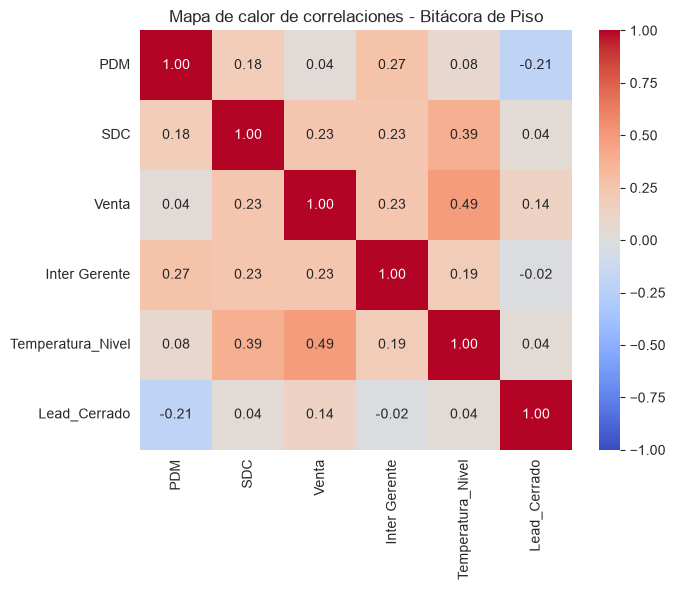

In [30]:
#Mapa de calor de correlaciones
plt.figure(figsize=(7, 6))
sns.heatmap(Corr_Bitacora, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones - Bitácora de Piso')
plt.tight_layout()
plt.show()


C:\Users\hdzmi\AppData\Local\Temp\ipykernel_2244\1544353699.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_venta.values, y=corr_venta.index, palette=colors)


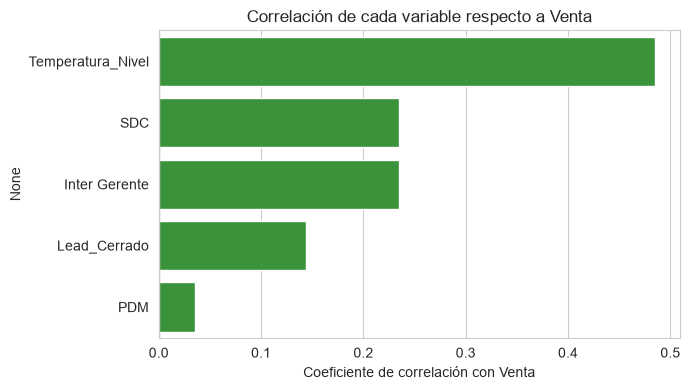

Temperatura_Nivel    0.485010
SDC                  0.234536
Inter Gerente        0.234492
Lead_Cerrado         0.143577
PDM                  0.035880
Name: Venta, dtype: float64

In [31]:
#Correlacion especifica de cada variable respecto a "Venta"
corr_venta = Corr_Bitacora['Venta'].drop('Venta').sort_values(ascending=False)

plt.figure(figsize=(7, 4))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in corr_venta.values]
sns.barplot(x=corr_venta.values, y=corr_venta.index, palette=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente de correlación con Venta')
plt.title('Correlación de cada variable respecto a Venta')
plt.tight_layout()
plt.show()

corr_venta


In [32]:
#Guardamos el DataFrame limpio de Bitacora de Piso
bit_clean.to_csv('bitacora_piso_limpio.csv', index=False)
print("Archivo generado: bitacora_piso_limpio.csv")

Archivo generado: bitacora_piso_limpio.csv


BASE DE DATOS TOPS MKT

In [3]:
#Cargamos el csv sin encabezado porque el archivo trae varios bloques/tablas apilados
tops_raw = pd.read_csv('Analisis_GAC_Full7agosto_2026_TOPS_MKT.csv', header=None, encoding='utf-8-sig')
tops_raw.head(12)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,AFLUENCIA A PISO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mes,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,NaN,NaN,NaN,NaN
2,Pisos minimos 2025,80,80,80,80,80,80,80,80,80,80,85,NaN,NaN,Minimo,Maximo,Promedio
3,Real pisos,76,64,80,43,65,59,63,71,58,72,81,NaN,NaN,43,81,66.54545455
4,% Real,95%,80%,100%,54%,81%,74%,79%,89%,73%,90%,95%,NaN,NaN,NaN,NaN,NaN
5,Pisos minimos,85,85,85,85,85,85,85,85,85,85,85,85,NaN,NaN,NaN,NaN
6,Real pisos,97,94,105,79,115,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Objetivo minimo,80%,80%,80%,80%,80%,80%,80%,80%,80%,80%,80%,80%,NaN,NaN,NaN,NaN
8,Objetivo ideal,85%,85%,85%,85%,85%,85%,85%,85%,85%,85%,85%,85%,NaN,NaN,NaN,NaN
9,Real,110%,111%,124%,93%,135%,100%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
meses_orden = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio ','Agosto',
               'Septiembre','Octubre','Noviembre','Diciembre']

def extraer_bloque(nombre_bloque, filas_dict):
    #Extrae la fila "Real" de cada bloque del dashboard (12 meses, columnas 1 a 12)
    datos = {}
    for etiqueta, fila in filas_dict.items():
        datos[f"{nombre_bloque}_{etiqueta}"] = tops_raw.iloc[fila, 1:13].tolist()
    return datos

bloques = {}
bloques.update(extraer_bloque('Afluencia',        {'RealPisos': 3}))
bloques.update(extraer_bloque('VentasPlaza',       {'RealVentas': 15}))
bloques.update(extraer_bloque('RedesSociales',     {'RealVisualizaciones': 26}))
bloques.update(extraer_bloque('UtilidadNeta',      {'Real': 36}))
bloques.update(extraer_bloque('RotacionPersonal',  {'Rotacion': 45}))
bloques.update(extraer_bloque('RecuperacionMarca', {'Real': 55}))

tops = pd.DataFrame(bloques, index=[m.strip() for m in meses_orden])
tops

,Afluencia_RealPisos,VentasPlaza_RealVentas,RedesSociales_RealVisualizaciones,UtilidadNeta_Real,RotacionPersonal_Rotacion,RecuperacionMarca_Real
Enero,76,6,40478,0.634,0,90%
Febrero,64,6,27979,1.333,0,100%
Marzo,80,7,28448,1.38,0,72%
Abril,43,7,32092,1.35,0,91%
Mayo,65,7,62405,0.85,0,92%
Junio,59,10,35280,NaN,0,85%
Julio,63,NaN,NaN,NaN,NaN,NaN
Agosto,71,NaN,NaN,NaN,NaN,NaN
Septiembre,58,NaN,NaN,NaN,NaN,NaN
Octubre,72,NaN,NaN,NaN,NaN,NaN


In [5]:
def limpiar_valor(v):
    #Convertimos strings con "%" o vacios a tipo numerico (float)
    if pd.isna(v):
        return np.nan
    if isinstance(v, str):
        v = v.strip().replace('%', '')
        if v == '':
            return np.nan
        return float(v)
    return float(v)

for c in tops.columns:
    tops[c] = tops[c].apply(limpiar_valor)

#Identificamos valores nulos por indicador (meses aun no reportados en el corte del 7-agosto-2026)
valores_nulos = tops.isnull().sum()
valores_nulos

Afluencia_RealPisos                  1
VentasPlaza_RealVentas               6
RedesSociales_RealVisualizaciones    6
UtilidadNeta_Real                    7
RotacionPersonal_Rotacion            6
RecuperacionMarca_Real               6
dtype: int64

In [6]:
#Como es una serie de tiempo mensual, sustituimos los nulos con interpolacion lineal CON AYUDA DE IA
#(metodo adecuado para datos secuenciales, similar en espiritu a ffill/bfill vistos en clase,
#pero que respeta la tendencia entre el mes anterior y el siguiente)
tops_clean = tops.interpolate(limit_direction='both')

#Corroboramos valores nulos
valores_nulos = tops_clean.isnull().sum()
valores_nulos

Afluencia_RealPisos                  0
VentasPlaza_RealVentas               0
RedesSociales_RealVisualizaciones    0
UtilidadNeta_Real                    0
RotacionPersonal_Rotacion            0
RecuperacionMarca_Real               0
dtype: int64

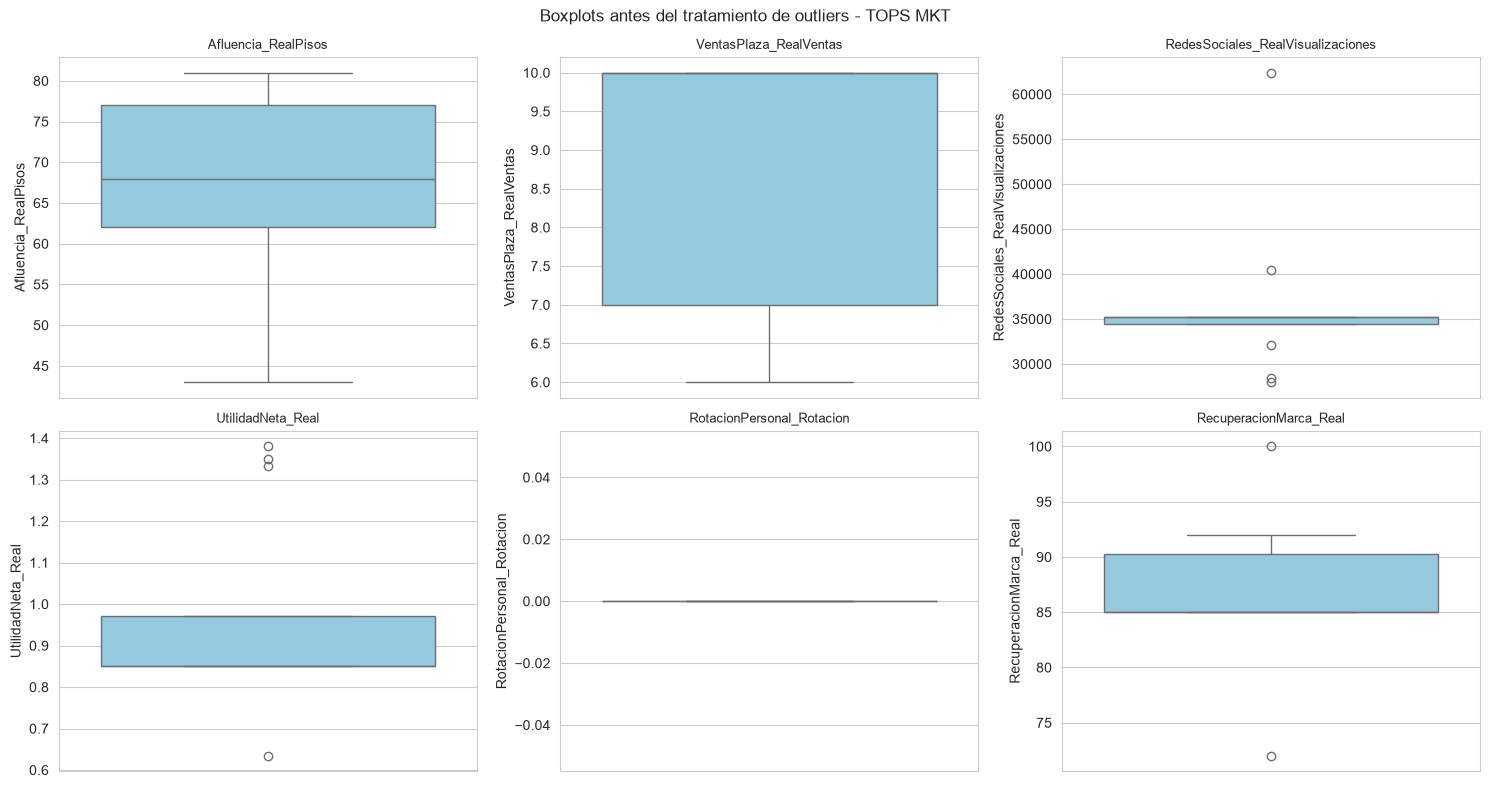

In [7]:
#Diagrama de caja de cada KPI antes de tratar outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), tops_clean.columns):
    sns.boxplot(y=tops_clean[col], ax=ax, color='skyblue')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots antes del tratamiento de outliers - TOPS MKT')
plt.tight_layout()
plt.show()


In [8]:
#Metodo IQR: detectamos limites y outliers, y aplicamos "capping" (winsorizacion)
#Se usa capping (no eliminacion) porque son solo 12 meses de datos y perder un mes
#rompe el analisis de tendencia
tops_capado = tops_clean.copy()
for c in tops_clean.columns:
    Q1 = tops_clean[c].quantile(0.25)
    Q3 = tops_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = tops_clean[(tops_clean[c] < li) | (tops_clean[c] > ls)]
    print(f"{c}: limites=({li:.1f}, {ls:.1f}) | outliers={len(outliers)}")
    tops_capado[c] = tops_capado[c].clip(lower=li, upper=ls)

tops_clean = tops_capado


Afluencia_RealPisos: limites=(39.5, 99.5) | outliers=0
VentasPlaza_RealVentas: limites=(2.5, 14.5) | outliers=0
RedesSociales_RealVisualizaciones: limites=(33287.5, 36475.5) | outliers=5
UtilidadNeta_Real: limites=(0.7, 1.2) | outliers=4
RotacionPersonal_Rotacion: limites=(0.0, 0.0) | outliers=0
RecuperacionMarca_Real: limites=(77.1, 98.1) | outliers=2


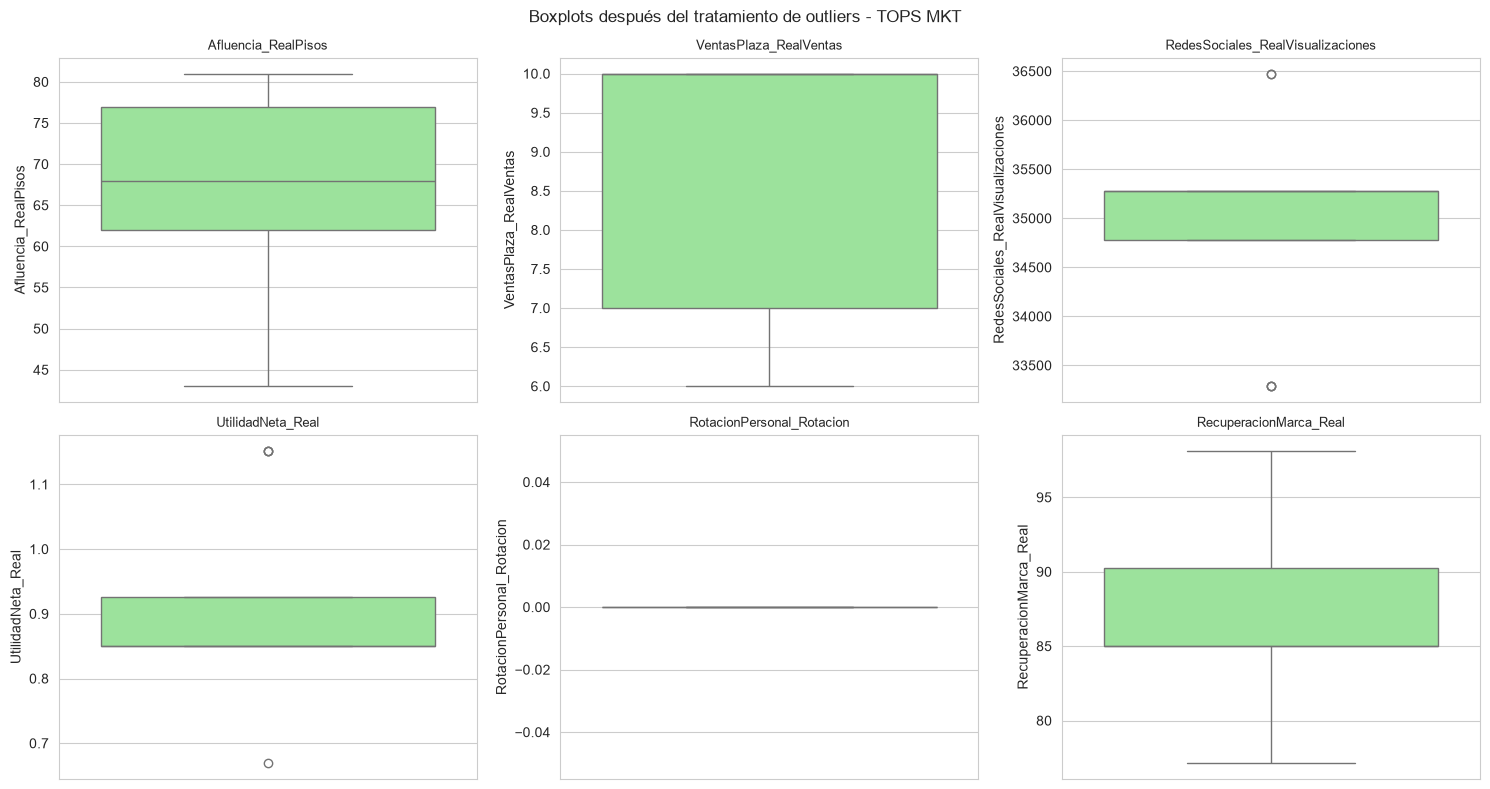

In [9]:
#Diagrama de caja despues del tratamiento de outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), tops_clean.columns):
    sns.boxplot(y=tops_clean[col], ax=ax, color='lightgreen')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots después del tratamiento de outliers - TOPS MKT')
plt.tight_layout()
plt.show()

Par de KPIs con mayor correlacion: ('RedesSociales_RealVisualizaciones', 'UtilidadNeta_Real') -> 0.952


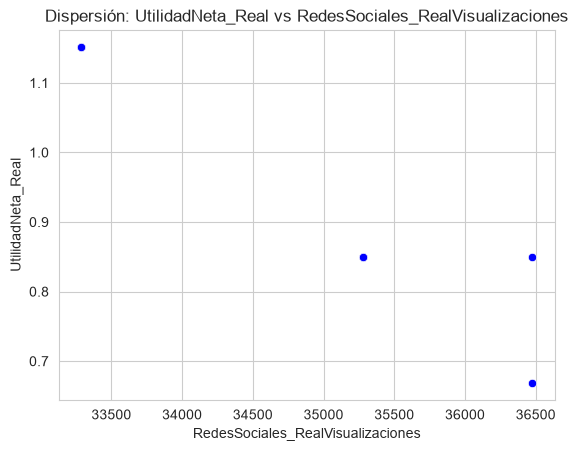

In [10]:
#Elegimos el par con mayor correlacion (en valor absoluto) dentro de la matriz de la seccion 2.3,
#excluyendo Rotacion (constante)
kpis = [c for c in tops_clean.columns if c != 'RotacionPersonal_Rotacion']
corr_kpis = tops_clean[kpis].corr().abs()
corr_vals = corr_kpis.values.copy()
np.fill_diagonal(corr_vals, 0)
corr_kpis = pd.DataFrame(corr_vals, index=corr_kpis.index, columns=corr_kpis.columns)
mejor_par = corr_kpis.stack().idxmax()
print("Par de KPIs con mayor correlacion:", mejor_par, "->", round(corr_kpis.loc[mejor_par], 3))

x_col, y_col = mejor_par

#Scatter plot de dispersion antes de ajustar el modelo
sns.scatterplot(x=x_col, y=y_col, color='blue', data=tops_clean)
plt.title(f'Dispersión: {y_col} vs {x_col}')
plt.show()


In [30]:
Var_Dep = tops_clean[y_col]
Vars_Indep = tops_clean[[x_col]]

model_tops = LinearRegression()
model_tops.fit(X=Vars_Indep, y=Var_Dep)

m = model_tops.coef_[0]
b = model_tops.intercept_
coef_Deter = model_tops.score(Vars_Indep, Var_Dep)
coef_Correl = np.sqrt(coef_Deter) if m >= 0 else -np.sqrt(coef_Deter)

print(f"Modelo matematico: {y_col} = {m:.4f} * {x_col} + {b:.4f}")
print(f"Coeficiente de Determinacion R2 = {coef_Deter:.4f}")
print(f"Coeficiente de Correlacion r = {coef_Correl:.4f}")
print(f"\nAdvertencia: n={len(tops_clean)} meses (varios interpolados) -> modelo poco robusto,")
print("util solo como referencia exploratoria, no para pronostico formal.")

Modelo matematico: UtilidadNeta_Real = -0.0001 * RedesSociales_RealVisualizaciones + 5.5189
Coeficiente de Determinacion R2 = 0.9058
Coeficiente de Correlacion r = -0.9517

Advertencia: n=12 meses (varios interpolados) -> modelo poco robusto,
util solo como referencia exploratoria, no para pronostico formal.


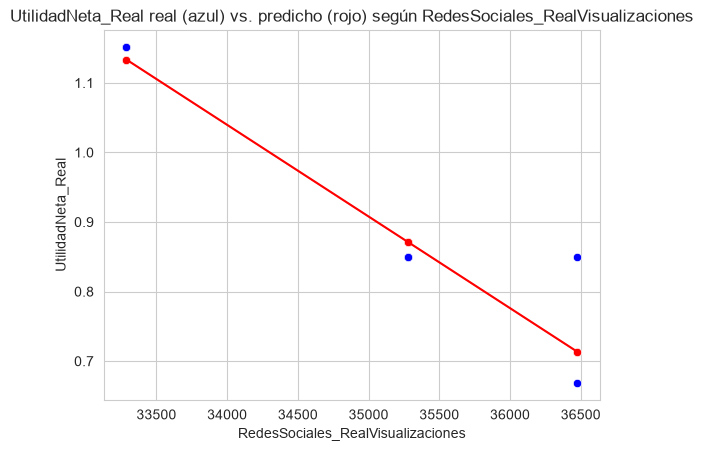

In [31]:
#Predecimos los valores de y_col a partir de x_col
tops_reg = tops_clean.copy()
tops_reg['Predicciones'] = model_tops.predict(Vars_Indep)

#Visualizamos la grafica comparativa entre los valores reales y los predichos
sns.scatterplot(x=x_col, y=y_col, color='blue', data=tops_reg)
sns.scatterplot(x=x_col, y='Predicciones', color='red', data=tops_reg)
sns.lineplot(x=x_col, y='Predicciones', color='red', data=tops_reg)
plt.title(f'{y_col} real (azul) vs. predicho (rojo) según {x_col}')
plt.show()


In [32]:
#Matriz de correlacion de los KPIs mensuales
#(Nota: "RotacionPersonal_Rotacion" es constante en 0 durante todo el periodo,
#por lo que su correlacion no esta definida -> apareceran NaN para esa columna)
Corr_Tops = tops_clean.corr()
Corr_Tops

,Afluencia_RealPisos,VentasPlaza_RealVentas,RedesSociales_RealVisualizaciones,UtilidadNeta_Real,RotacionPersonal_Rotacion,RecuperacionMarca_Real
Afluencia_RealPisos,1.000000,0.124351,0.278702,-0.330782,NaN,-0.416643
VentasPlaza_RealVentas,0.124351,1.000000,0.296113,-0.418829,NaN,-0.537461
RedesSociales_RealVisualizaciones,0.278702,0.296113,1.000000,-0.951734,NaN,-0.017507
UtilidadNeta_Real,-0.330782,-0.418829,-0.951734,1.000000,NaN,0.122631
RotacionPersonal_Rotacion,NaN,NaN,NaN,NaN,NaN,NaN
RecuperacionMarca_Real,-0.416643,-0.537461,-0.017507,0.122631,NaN,1.000000


In [33]:
#Matriz de correlacion de los KPIs mensuales, excluyendo Rotacion (es constante = correlacion indefinida)
#esto lo hice por que en las correlaciones rotacion de personal sale con 0
kpis_corr = [c for c in tops_clean.columns if c != 'RotacionPersonal_Rotacion']
Corr_Tops = tops_clean[kpis_corr].corr()
Corr_Tops

,Afluencia_RealPisos,VentasPlaza_RealVentas,RedesSociales_RealVisualizaciones,UtilidadNeta_Real,RecuperacionMarca_Real
Afluencia_RealPisos,1.000000,0.124351,0.278702,-0.330782,-0.416643
VentasPlaza_RealVentas,0.124351,1.000000,0.296113,-0.418829,-0.537461
RedesSociales_RealVisualizaciones,0.278702,0.296113,1.000000,-0.951734,-0.017507
UtilidadNeta_Real,-0.330782,-0.418829,-0.951734,1.000000,0.122631
RecuperacionMarca_Real,-0.416643,-0.537461,-0.017507,0.122631,1.000000


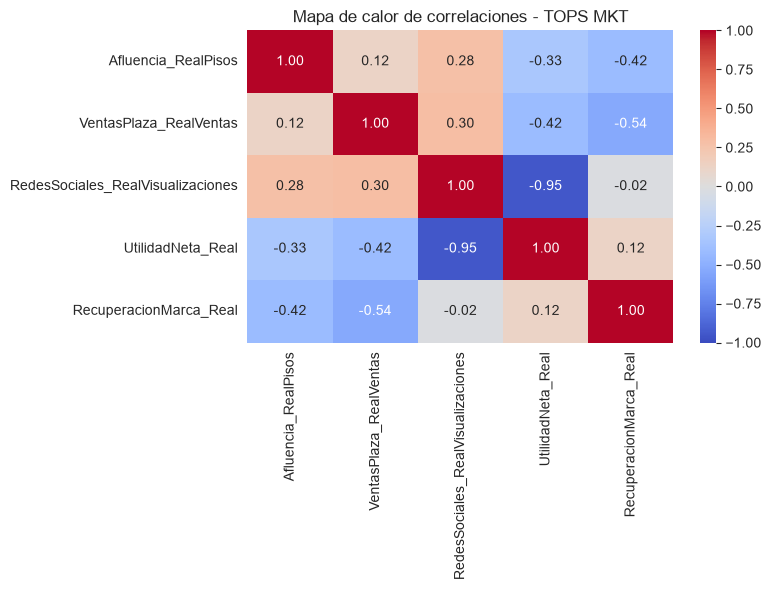

In [34]:
#Mapa de calor de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(Corr_Tops, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones - TOPS MKT')
plt.tight_layout()
plt.show()


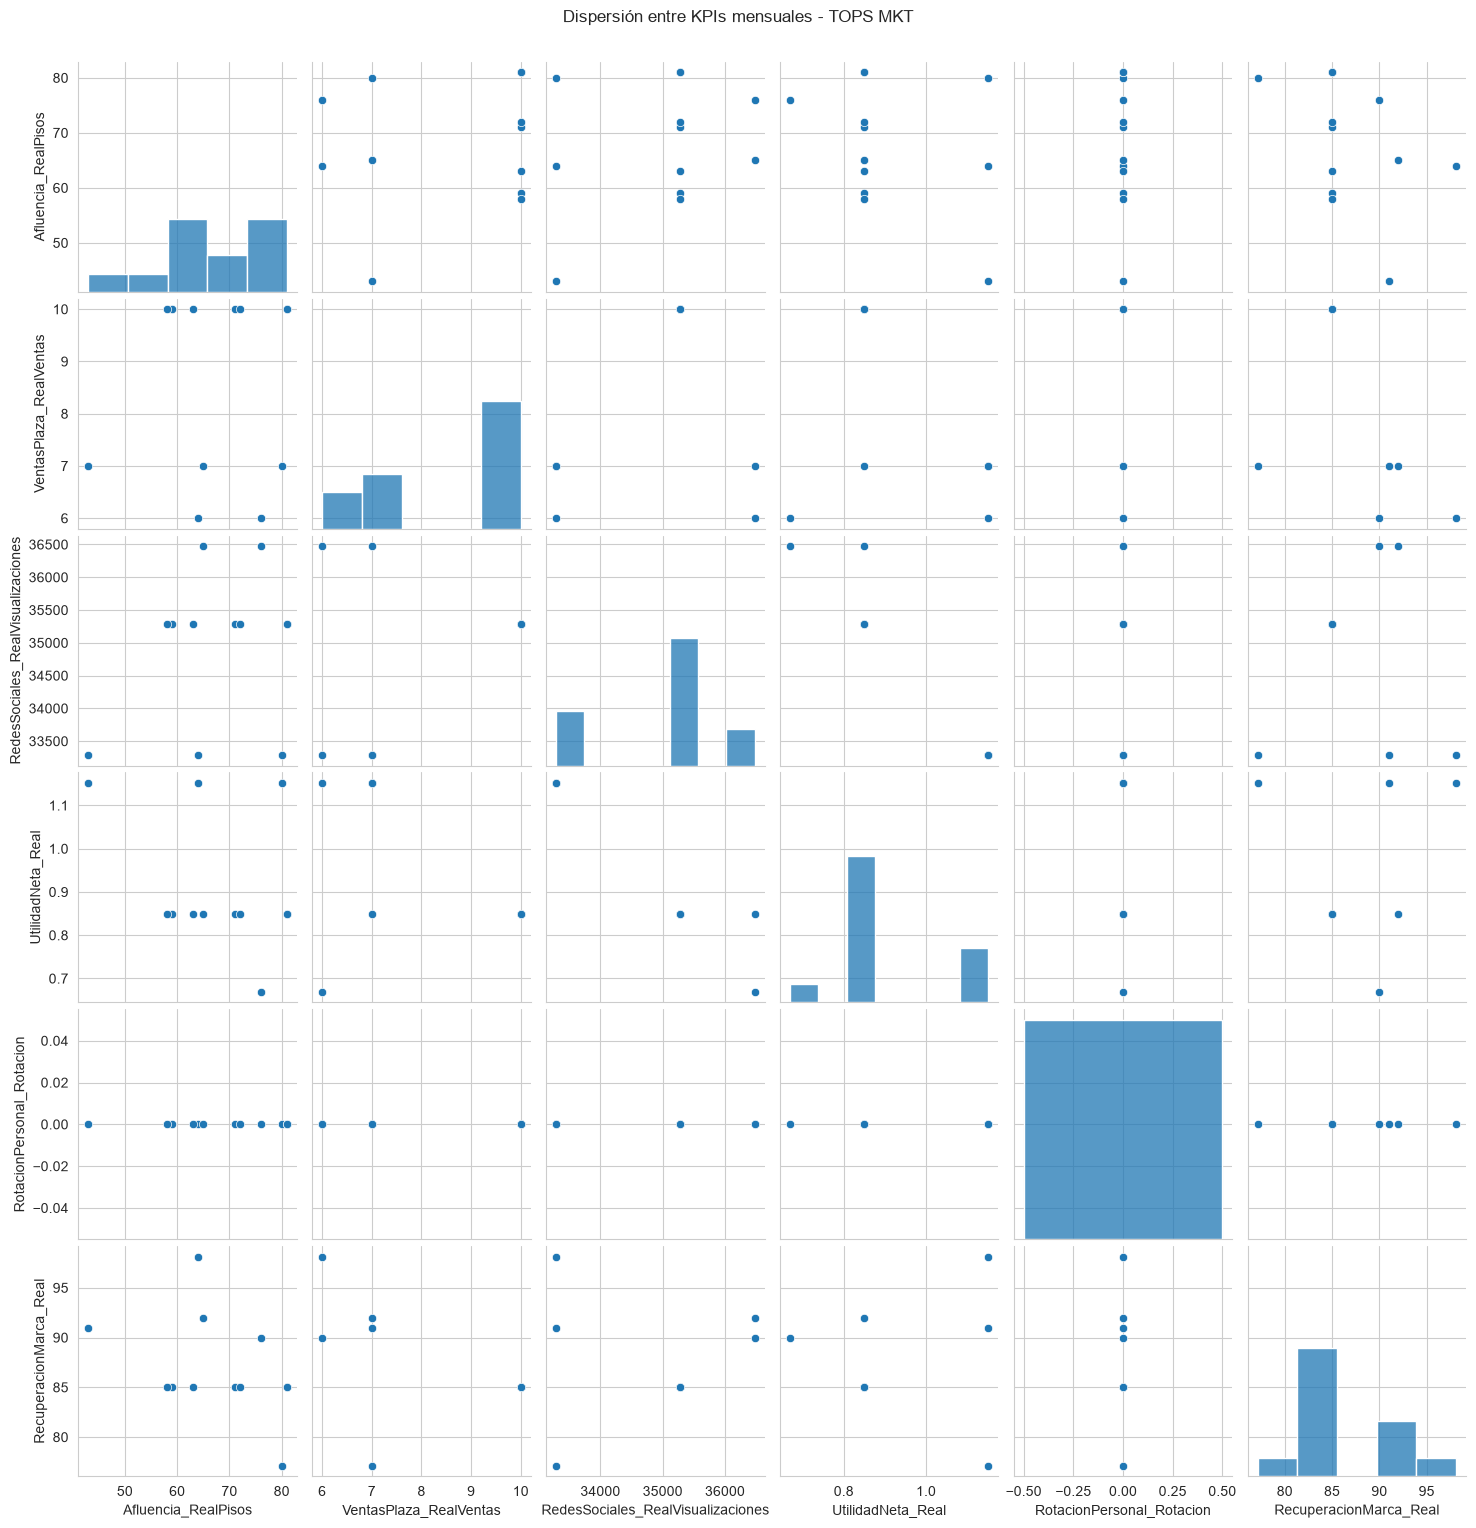

In [35]:
#Dispersion entre todos los KPIs
sns.pairplot(tops_clean)
plt.suptitle('Dispersión entre KPIs mensuales - TOPS MKT', y=1.02)
plt.show()

In [36]:
#Guardamos el DataFrame limpio de TOPS MKT
tops_clean.to_csv('tops_mkt_limpio.csv')
print("Archivo generado: tops_mkt_limpio.csv")

Archivo generado: tops_mkt_limpio.csv


BASE 3 tops tdh

In [37]:
#Cargamos el csv sin encabezado (mismo formato de reporte apilado que TOPS MKT)
tdh_raw = pd.read_csv('Analisis_GAC_Full7agosto_2026_TOPS_TDH.csv', header=None, encoding='utf-8-sig')
tdh_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57
0,INDICADORES GENERALES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026 /certificación de marca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mes,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Plantilla,29,29,29,30,31,33,33,34,35,36,36,36,37,40,42,44,44,44,44,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Operando,28,24,26,27,28,29,30,32,34,34,34,32,33,37,38,40,40,42,42,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cumplimiento de plantilla,97%,83%,90%,90%,90%,88%,91%,94%,97%,94%,94%,89%,89%,93%,90%,91%,91%,95%,95%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Bajas,3,1,6,0,1,3,2,2,1,1,1,2,3,0,0,2,0,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Vacantes,1,5,3,3,3,4,3,2,2,2,3,3,4,3,4,4,4,2,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Índice de Rotación,10%,3%,21%,0%,3%,9%,6%,6%,3%,3%,3%,6%,8%,0%,0%,5%,0%,5%,5%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
#Etiquetas de mes para las 24 columnas (Ene-25...Dic-25, Ene-26...Dic-26)
meses_2025 = ['Ene-25','Feb-25','Mar-25','Abr-25','May-25','Jun-25','Jul-25','Ago-25',
              'Sep-25','Oct-25','Nov-25','Dic-25']
meses_2026 = ['Ene-26','Feb-26','Mar-26','Abr-26','May-26','Jun-26','Jul-26','Ago-26',
              'Sep-26','Oct-26','Nov-26','Dic-26']
meses_completo = meses_2025 + meses_2026

#Filas de interes dentro del bloque "INDICADORES GENERALES" y "APVS QUE CUMPLIERON SU META"
filas_tdh = {
    'Plantilla': 4,
    'Operando': 5,
    'Productividad_APVS': 12,
    'Total_Apvs': 43,
    'Apvs_Cumplieron': 44
}

tdh = pd.DataFrame(
    {nombre: tdh_raw.iloc[idx, 1:25].tolist() for nombre, idx in filas_tdh.items()},
    index=meses_completo
)
tdh

,Plantilla,Operando,Productividad_APVS,Total_Apvs,Apvs_Cumplieron
Ene-25,29,28,61%,5,2
Feb-25,29,24,42%,6,2
Mar-25,29,26,86%,8,3
Abr-25,30,27,90%,9,4
May-25,31,28,91%,11,5
Jun-25,33,29,95%,14,12
Jul-25,33,30,78%,14,6
Ago-25,34,32,54%,13,2
Sep-25,35,34,87%,12,7
Oct-25,36,34,76%,15,6


In [39]:
def limpiar_valor_tdh(v):
    #Convertimos strings con "%" a tipo numerico; tratamos errores de formula (#DIV/0!) como nulo
    if pd.isna(v):
        return np.nan
    if isinstance(v, str):
        v = v.strip().replace('%', '')
        if v == '' or v == '#DIV/0!':
            return np.nan
        return float(v)
    return float(v)

for c in tdh.columns:
    tdh[c] = tdh[c].apply(limpiar_valor_tdh)

#Identificamos valores nulos por indicador
valores_nulos = tdh.isnull().sum()
valores_nulos


Plantilla             5
Operando              5
Productividad_APVS    6
Total_Apvs            6
Apvs_Cumplieron       6
dtype: int64

In [40]:
#IMPORTANTE: a diferencia de TOPS MKT, aqui los nulos NO son huecos a la mitad de la serie,
#son meses que sencillamente aun no han ocurrido (el corte de datos es el 7 de agosto de 2026).
#Por eso NO se interpola (interpolar inventaria un valor futuro); simplemente se eliminan
#las filas de meses sin ningun dato registrado todavia.
tdh_clean = tdh.dropna(how='all')
print("Forma tras eliminar meses futuros sin datos:", tdh_clean.shape)
tdh_clean.tail(8)

Forma tras eliminar meses futuros sin datos: (19, 5)


,Plantilla,Operando,Productividad_APVS,Total_Apvs,Apvs_Cumplieron
Dic-25,36.0,32.0,60.0,14.0,4.0
Ene-26,37.0,33.0,91.0,11.0,7.0
Feb-26,40.0,37.0,67.0,15.0,7.0
Mar-26,42.0,38.0,71.0,15.0,7.0
Abr-26,44.0,40.0,74.0,14.0,7.0
May-26,44.0,40.0,82.0,12.0,4.0
Jun-26,44.0,42.0,82.0,12.0,5.0
Jul-26,44.0,42.0,NaN,NaN,NaN


In [41]:
#Corroboramos nulos restantes (pueden quedar algunos residuales por indicador)
valores_nulos = tdh_clean.isnull().sum()
valores_nulos


Plantilla             0
Operando              0
Productividad_APVS    1
Total_Apvs            1
Apvs_Cumplieron       1
dtype: int64

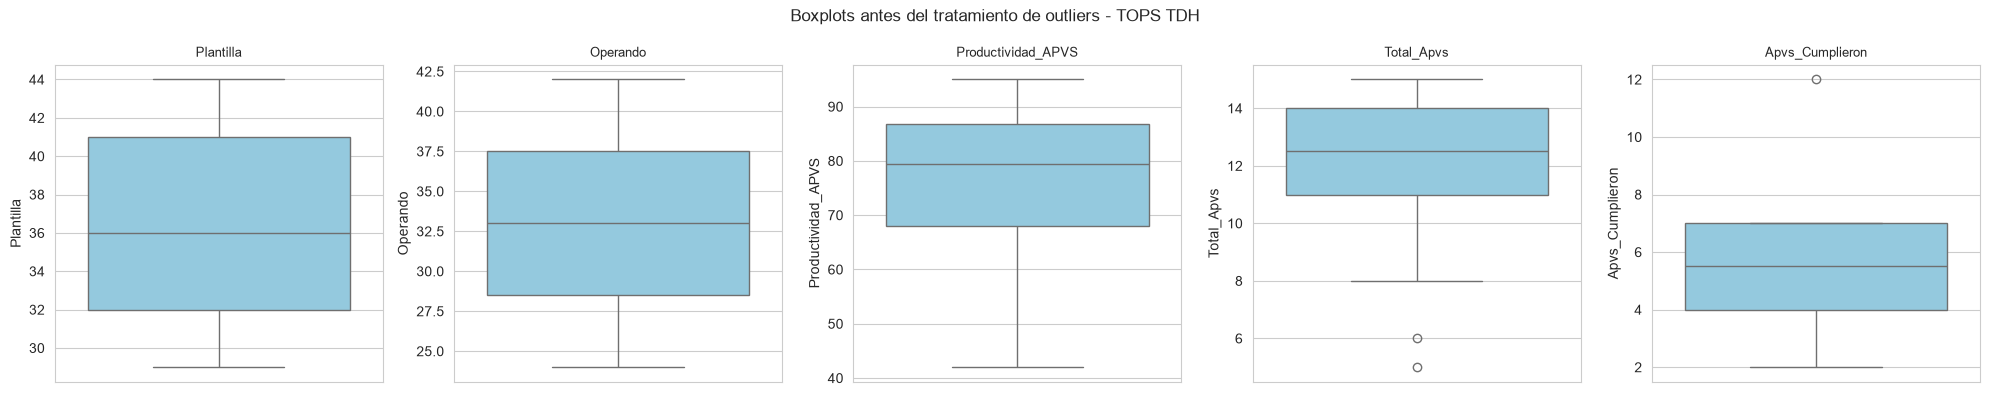

In [42]:
#Diagrama de caja antes del tratamiento de outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, tdh_clean.columns):
    sns.boxplot(y=tdh_clean[col].dropna(), ax=ax, color='skyblue')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots antes del tratamiento de outliers - TOPS TDH')
plt.tight_layout()
plt.show()


In [43]:
#Metodo IQR: detectamos limites y outliers, y aplicamos "capping" (winsorizacion)
#Se usa capping (no eliminacion de meses) porque la muestra ya es pequeña (18 meses)
tdh_capado = tdh_clean.copy()
for c in tdh_clean.columns:
    serie = tdh_clean[c].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = tdh_clean[(tdh_clean[c] < li) | (tdh_clean[c] > ls)]
    print(f"{c}: limites=({li:.1f}, {ls:.1f}) | outliers={len(outliers)}")
    tdh_capado[c] = tdh_capado[c].clip(lower=li, upper=ls)

tdh_clean = tdh_capado

Plantilla: limites=(18.5, 54.5) | outliers=0
Operando: limites=(15.0, 51.0) | outliers=0
Productividad_APVS: limites=(39.9, 114.9) | outliers=0
Total_Apvs: limites=(6.5, 18.5) | outliers=2
Apvs_Cumplieron: limites=(-0.5, 11.5) | outliers=1


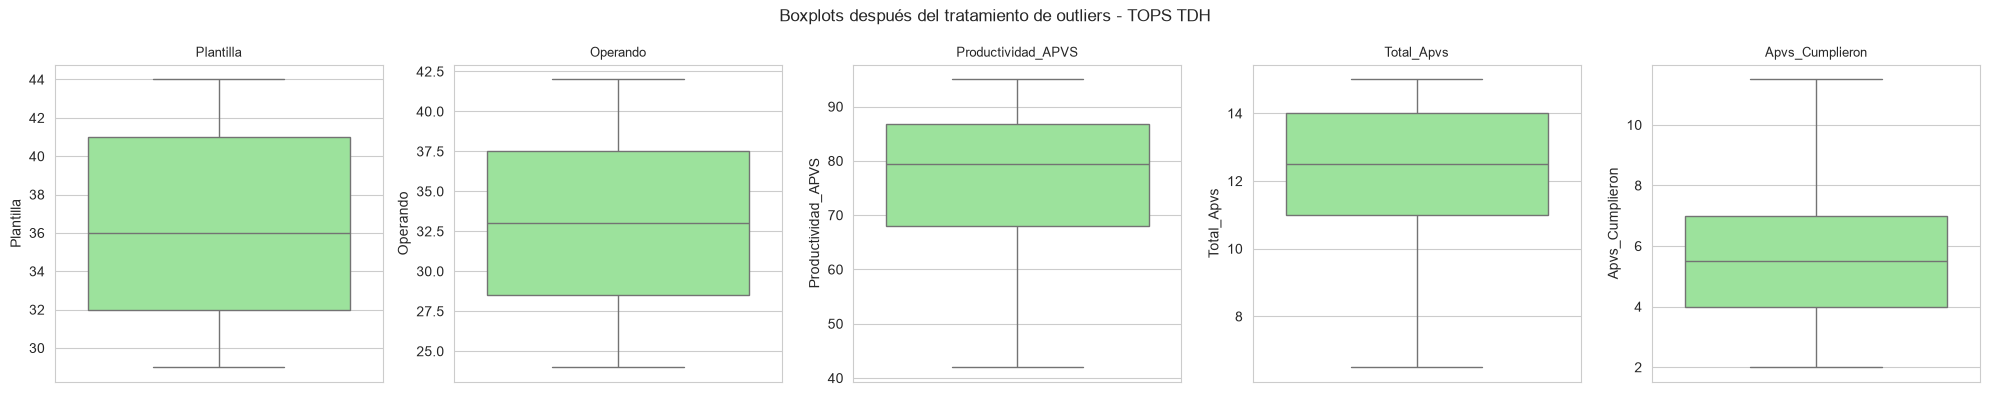

In [44]:
#Diagrama de caja despues del tratamiento de outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, tdh_clean.columns):
    sns.boxplot(y=tdh_clean[col].dropna(), ax=ax, color='lightgreen')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots después del tratamiento de outliers - TOPS TDH')
plt.tight_layout()
plt.show()


In [45]:
#Guardamos el DataFrame limpio de TOPS TDH
tdh_clean.to_csv('tops_tdh_limpio.csv')
print("Archivo generado: tops_tdh_limpio.csv")

Archivo generado: tops_tdh_limpio.csv


¿Tener más personal se traduce en mejor productividad promedio, o la diluye?

In [46]:
df_plantilla = tdh_clean[['Plantilla', 'Operando', 'Productividad_APVS']].dropna()

Corr_Plantilla = df_plantilla.corr()
Corr_Plantilla

,Plantilla,Operando,Productividad_APVS
Plantilla,1.000000,0.976601,0.086989
Operando,0.976601,1.000000,0.112819
Productividad_APVS,0.086989,0.112819,1.000000


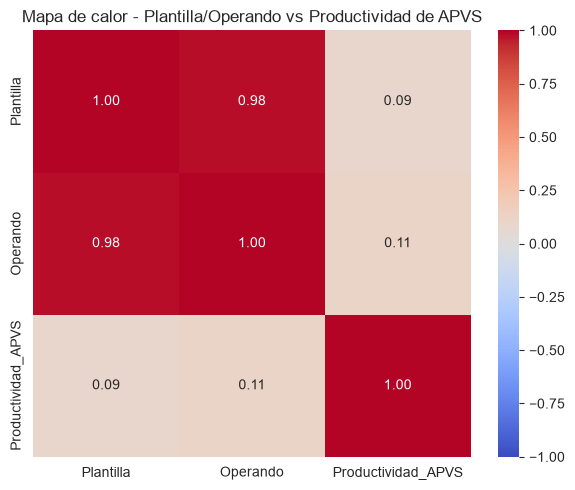

In [47]:
plt.figure(figsize=(6, 5))
sns.heatmap(Corr_Plantilla, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor - Plantilla/Operando vs Productividad de APVS')
plt.tight_layout()
plt.show()

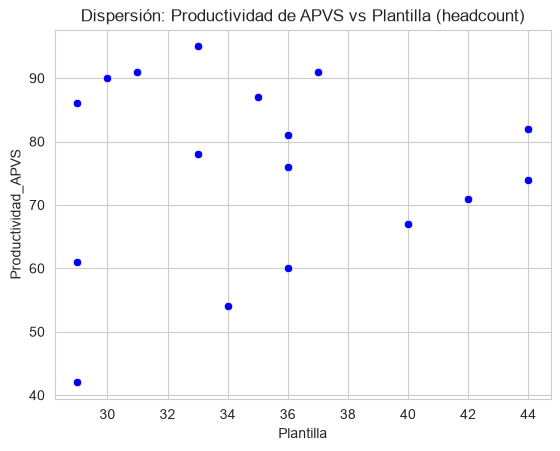

In [48]:
#Imprimimos el scatter plot entre la variable dependiente (Productividad_APVS) y la
#independiente (Plantilla) para observar el comportamiento de su dispersión
sns.scatterplot(x='Plantilla', y='Productividad_APVS', color='blue', data=df_plantilla)
plt.title('Dispersión: Productividad de APVS vs Plantilla (headcount)')
plt.show()

In [49]:
#Regresion Lineal Simple: Productividad_APVS ~ Plantilla
Var_Dep = df_plantilla['Productividad_APVS']
Vars_Indep = df_plantilla[['Plantilla']]

model_plantilla = LinearRegression()
model_plantilla.fit(X=Vars_Indep, y=Var_Dep)

m = model_plantilla.coef_[0]
b = model_plantilla.intercept_
coef_Deter = model_plantilla.score(Vars_Indep, Var_Dep)
coef_Correl = np.sqrt(coef_Deter) if m >= 0 else -np.sqrt(coef_Deter)

print(f"Modelo matematico: Productividad_APVS = {m:.4f} * Plantilla + {b:.4f}")
print(f"Coeficiente de Determinacion R2 = {coef_Deter:.4f}")
print(f"Coeficiente de Correlacion r = {coef_Correl:.4f}")

if abs(coef_Correl) < 0.3:
    conclusion = "No hay una relacion lineal relevante: crecer la plantilla NO diluye ni mejora la productividad promedio de forma significativa."
elif coef_Correl >= 0.3:
    conclusion = "Relacion positiva: a mayor plantilla, mayor productividad promedio (economias de escala / mejor cobertura)."
else:
    conclusion = "Relacion negativa: a mayor plantilla, menor productividad promedio (posible dilucion del desempeño)."
print("\nConclusion:", conclusion)

Modelo matematico: Productividad_APVS = 0.2384 * Plantilla + 67.4972
Coeficiente de Determinacion R2 = 0.0076
Coeficiente de Correlacion r = 0.0870

Conclusion: No hay una relacion lineal relevante: crecer la plantilla NO diluye ni mejora la productividad promedio de forma significativa.


In [50]:
#Predecimos los valores de Productividad_APVS a partir de la Plantilla
df_plantilla['Predicciones'] = model_plantilla.predict(Vars_Indep)
df_plantilla[['Plantilla', 'Productividad_APVS', 'Predicciones']]

,Plantilla,Productividad_APVS,Predicciones
Ene-25,29.0,61.0,74.410689
Feb-25,29.0,42.0,74.410689
Mar-25,29.0,86.0,74.410689
Abr-25,30.0,90.0,74.649086
May-25,31.0,91.0,74.887482
Jun-25,33.0,95.0,75.364276
Jul-25,33.0,78.0,75.364276
Ago-25,34.0,54.0,75.602672
Sep-25,35.0,87.0,75.841069
Oct-25,36.0,76.0,76.079466


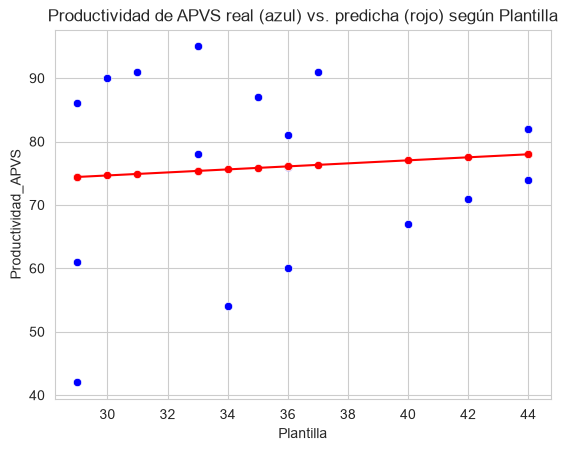

In [51]:
#Visualizamos la grafica comparativa entre la Productividad real y la predecida
sns.scatterplot(x='Plantilla', y='Productividad_APVS', color='blue', data=df_plantilla)
sns.scatterplot(x='Plantilla', y='Predicciones', color='red', data=df_plantilla)
sns.lineplot(x='Plantilla', y='Predicciones', color='red', data=df_plantilla)
plt.title('Productividad de APVS real (azul) vs. predicha (rojo) según Plantilla')
plt.show()



¿Qué tan escalable es el cumplimiento de metas conforme crece el equipo? Para responder esto no
basta con mirar el número absoluto de asesores que cumplen (que casi por definición crece si hay
más asesores); calculamos también el **porcentaje de cumplimiento** (`Apvs_Cumplieron / Total_Apvs`)
para ver si esa tasa se mantiene, mejora o se diluye conforme el equipo crece.

In [52]:
df_metas = tdh_clean[['Total_Apvs', 'Apvs_Cumplieron']].dropna().copy()
df_metas['Pct_Cumplimiento'] = df_metas['Apvs_Cumplieron'] / df_metas['Total_Apvs'] * 100

df_metas


,Total_Apvs,Apvs_Cumplieron,Pct_Cumplimiento
Ene-25,6.5,2.0,30.769231
Feb-25,6.5,2.0,30.769231
Mar-25,8.0,3.0,37.500000
Abr-25,9.0,4.0,44.444444
May-25,11.0,5.0,45.454545
Jun-25,14.0,11.5,82.142857
Jul-25,14.0,6.0,42.857143
Ago-25,13.0,2.0,15.384615
Sep-25,12.0,7.0,58.333333
Oct-25,15.0,6.0,40.000000


In [54]:
Corr_Metas = df_metas.corr()
Corr_Metas


,Total_Apvs,Apvs_Cumplieron,Pct_Cumplimiento
Total_Apvs,1.000000,0.647006,0.261258
Apvs_Cumplieron,0.647006,1.000000,0.898111
Pct_Cumplimiento,0.261258,0.898111,1.000000


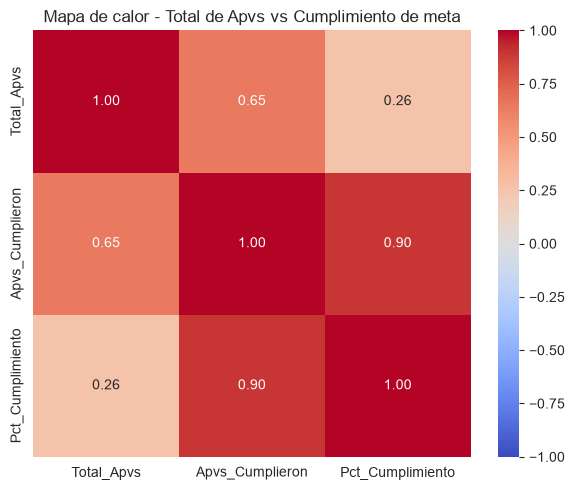

In [55]:
plt.figure(figsize=(6, 5))
sns.heatmap(Corr_Metas, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor - Total de Apvs vs Cumplimiento de meta')
plt.tight_layout()
plt.show()

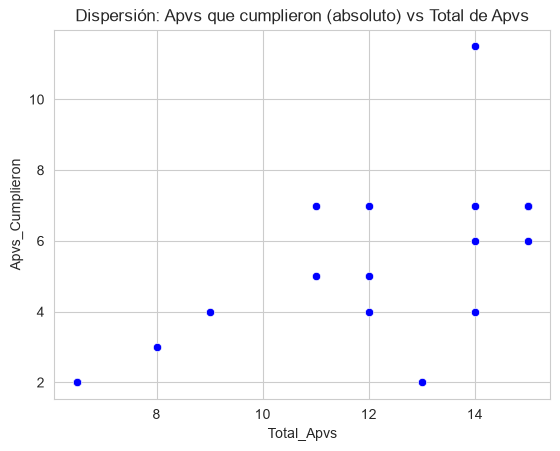

In [56]:
#Dispersion antes de ajustar el modelo: Apvs que cumplieron (absoluto) vs Total de Apvs
sns.scatterplot(x='Total_Apvs', y='Apvs_Cumplieron', color='blue', data=df_metas)
plt.title('Dispersión: Apvs que cumplieron (absoluto) vs Total de Apvs')
plt.show()

In [57]:
#Regresion Lineal Simple: Apvs_Cumplieron (absoluto) ~ Total_Apvs
Var_Dep = df_metas['Apvs_Cumplieron']
Vars_Indep = df_metas[['Total_Apvs']]

model_metas_abs = LinearRegression()
model_metas_abs.fit(X=Vars_Indep, y=Var_Dep)

m = model_metas_abs.coef_[0]
b = model_metas_abs.intercept_
coef_Deter = model_metas_abs.score(Vars_Indep, Var_Dep)
coef_Correl = np.sqrt(coef_Deter) if m >= 0 else -np.sqrt(coef_Deter)

print(f"Modelo matematico: Apvs_Cumplieron = {m:.4f} * Total_Apvs + {b:.4f}")
print(f"Coeficiente de Determinacion R2 = {coef_Deter:.4f}")
print(f"Coeficiente de Correlacion r = {coef_Correl:.4f}")

Modelo matematico: Apvs_Cumplieron = 0.5457 * Total_Apvs + -1.2175
Coeficiente de Determinacion R2 = 0.4186
Coeficiente de Correlacion r = 0.6470


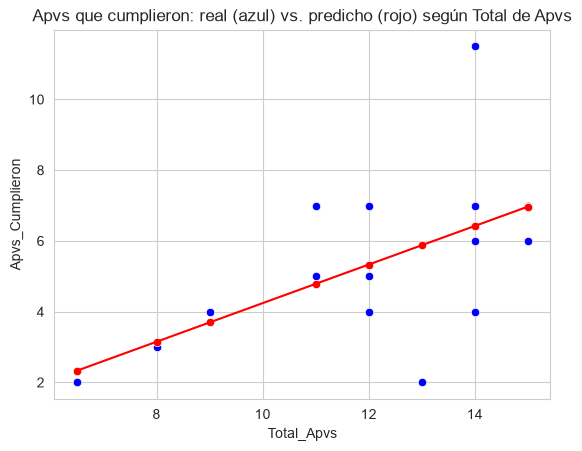

In [58]:
#Predecimos y graficamos real vs prediccion (valores absolutos)
df_metas['Predicciones_Abs'] = model_metas_abs.predict(Vars_Indep)

sns.scatterplot(x='Total_Apvs', y='Apvs_Cumplieron', color='blue', data=df_metas)
sns.scatterplot(x='Total_Apvs', y='Predicciones_Abs', color='red', data=df_metas)
sns.lineplot(x='Total_Apvs', y='Predicciones_Abs', color='red', data=df_metas)
plt.title('Apvs que cumplieron: real (azul) vs. predicho (rojo) según Total de Apvs')
plt.show()


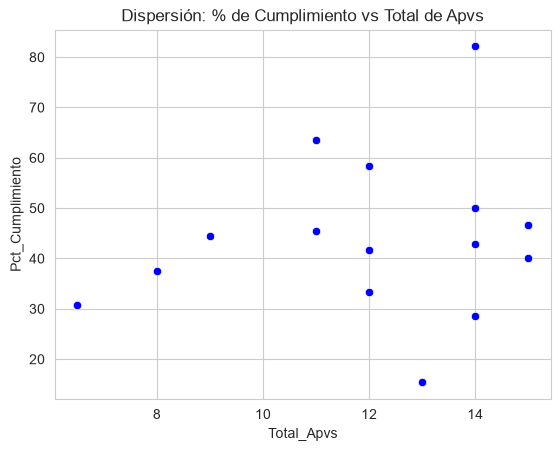

In [59]:
#Dispersion antes de ajustar el modelo: % de Cumplimiento (tasa) vs Total de Apvs
#Esta es la variable que realmente responde la pregunta de "escalabilidad"
sns.scatterplot(x='Total_Apvs', y='Pct_Cumplimiento', color='blue', data=df_metas)
plt.title('Dispersión: % de Cumplimiento vs Total de Apvs')
plt.show()


In [61]:
#Regresion Lineal Simple: % Cumplimiento ~ Total de Apvs (esta es la que responde "escalabilidad")
Var_Dep = df_metas['Pct_Cumplimiento']
Vars_Indep = df_metas[['Total_Apvs']]

model_metas = LinearRegression()
model_metas.fit(X=Vars_Indep, y=Var_Dep)

m = model_metas.coef_[0]
b = model_metas.intercept_
coef_Deter = model_metas.score(Vars_Indep, Var_Dep)
coef_Correl = np.sqrt(coef_Deter) if m >= 0 else -np.sqrt(coef_Deter)

print(f"Modelo matematico: %Cumplimiento = {m:.4f} * Total_Apvs + {b:.4f}")
print(f"Coeficiente de Determinacion R2 = {coef_Deter:.4f}")
print(f"Coeficiente de Correlacion r = {coef_Correl:.4f}")

if coef_Correl <= -0.3:
    conclusion = "El cumplimiento de metas NO es escalable: conforme crece el equipo, el % de asesores que cumplen su meta tiende a bajar (dilucion)."
elif coef_Correl >= 0.3:
    conclusion = "El cumplimiento de metas SI escala bien: conforme crece el equipo, el % de asesores que cumplen su meta se mantiene o mejora."
else:
    conclusion = "El tamaño del equipo no tiene una relacion lineal fuerte con la TASA de cumplimiento: crece el numero absoluto de asesores que cumplen, pero el porcentaje se mantiene relativamente estable (ni mejora ni se diluye claramente)."
print("\nConclusion:", conclusion)


Modelo matematico: %Cumplimiento = 1.3389 * Total_Apvs + 27.4626
Coeficiente de Determinacion R2 = 0.0683
Coeficiente de Correlacion r = 0.2613

Conclusion: El tamaño del equipo no tiene una relacion lineal fuerte con la TASA de cumplimiento: crece el numero absoluto de asesores que cumplen, pero el porcentaje se mantiene relativamente estable (ni mejora ni se diluye claramente).


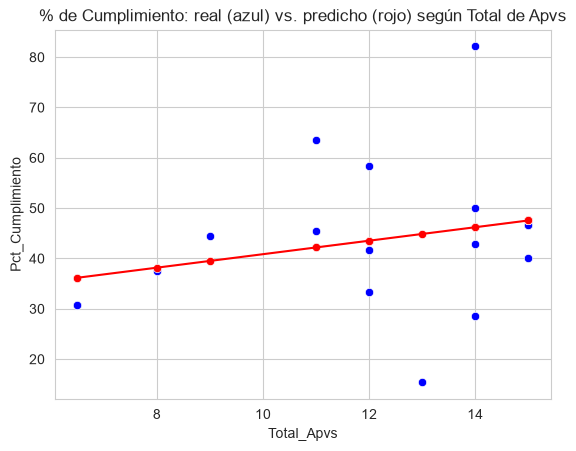

In [62]:
#Predecimos y graficamos real vs prediccion (tasa de cumplimiento)
df_metas['Predicciones_Pct'] = model_metas.predict(Vars_Indep)

sns.scatterplot(x='Total_Apvs', y='Pct_Cumplimiento', color='blue', data=df_metas)
sns.scatterplot(x='Total_Apvs', y='Predicciones_Pct', color='red', data=df_metas)
sns.lineplot(x='Total_Apvs', y='Predicciones_Pct', color='red', data=df_metas)
plt.title('% de Cumplimiento: real (azul) vs. predicho (rojo) según Total de Apvs')
plt.show()

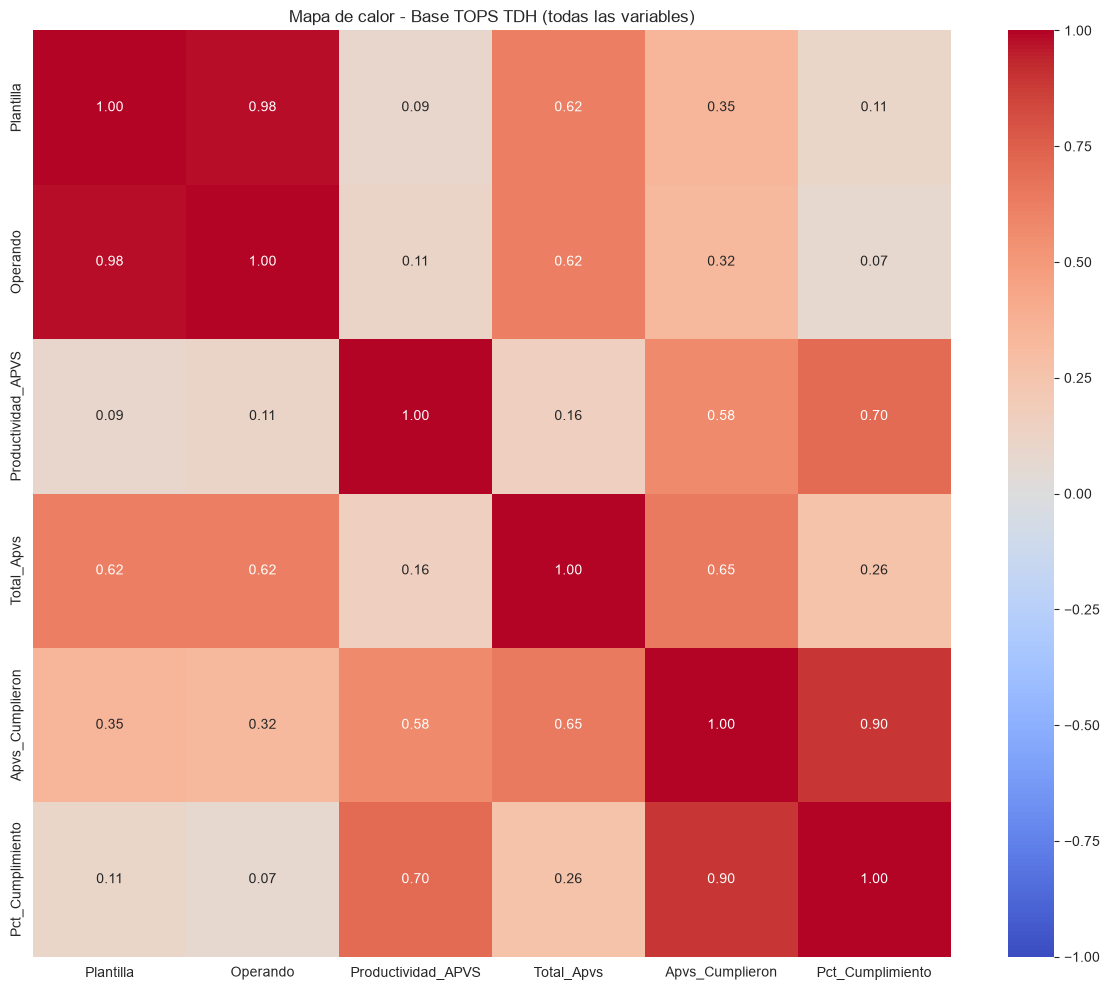

Ranking - variables más correlacionadas con Productividad_APVS:
 Pct_Cumplimiento    0.703259
Apvs_Cumplieron     0.577664
Total_Apvs          0.161930
Operando            0.112819
Plantilla           0.086989
Name: Productividad_APVS, dtype: float64

Ranking - variables más correlacionadas con Pct_Cumplimiento:
 Productividad_APVS    0.703259
Plantilla             0.106344
Operando              0.073876
Name: Pct_Cumplimiento, dtype: float64


In [63]:
# ============================================================
# MAPA DE CALOR UNIFICADO - Base TOPS TDH (todas las variables)
# ============================================================

# Juntamos Total_Apvs/Apvs_Cumplieron (que ya estaban en tdh_clean)
# con el % de Cumplimiento calculado, todo en un solo dataframe
df_tdh_full = tdh_clean.copy()
df_tdh_full['Pct_Cumplimiento'] = df_tdh_full['Apvs_Cumplieron'] / df_tdh_full['Total_Apvs'] * 100

Corr_TDH = df_tdh_full.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(Corr_TDH, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de calor - Base TOPS TDH (todas las variables)')
plt.tight_layout()
plt.show()

# Ranking para elegir la variable independiente de cada regresión,
# excluyendo variables "circulares" (miden lo mismo que la variable dependiente)
excluir_prod = ['Productividad_APVS', 'Indice_Clima']
excluir_cump = ['Pct_Cumplimiento', 'Total_Apvs', 'Apvs_Cumplieron',
                'Pct_Apvs_Cumplieron_Reportado', 'Indice_Clima']

ranking_productividad = Corr_TDH['Productividad_APVS'].drop(excluir_prod, errors='ignore').abs().sort_values(ascending=False)
ranking_cumplimiento = Corr_TDH['Pct_Cumplimiento'].drop(excluir_cump, errors='ignore').abs().sort_values(ascending=False)

print("Ranking - variables más correlacionadas con Productividad_APVS:\n", ranking_productividad)
print("\nRanking - variables más correlacionadas con Pct_Cumplimiento:\n", ranking_cumplimiento)